PRESENT CIPHER

Logistic Regression

Dataset Generation + Logistic Regression

Starting Logistic Regression on PRESENT Cipher (Samples: 15000)
Processing Round 1...
-> Round 1 | Accuracy: 0.6555 | Avg Hamming Distance: 22.05
Processing Round 2...
-> Round 2 | Accuracy: 0.5357 | Avg Hamming Distance: 29.71
Processing Round 3...
-> Round 3 | Accuracy: 0.5097 | Avg Hamming Distance: 31.38
Processing Round 4...
-> Round 4 | Accuracy: 0.5017 | Avg Hamming Distance: 31.89


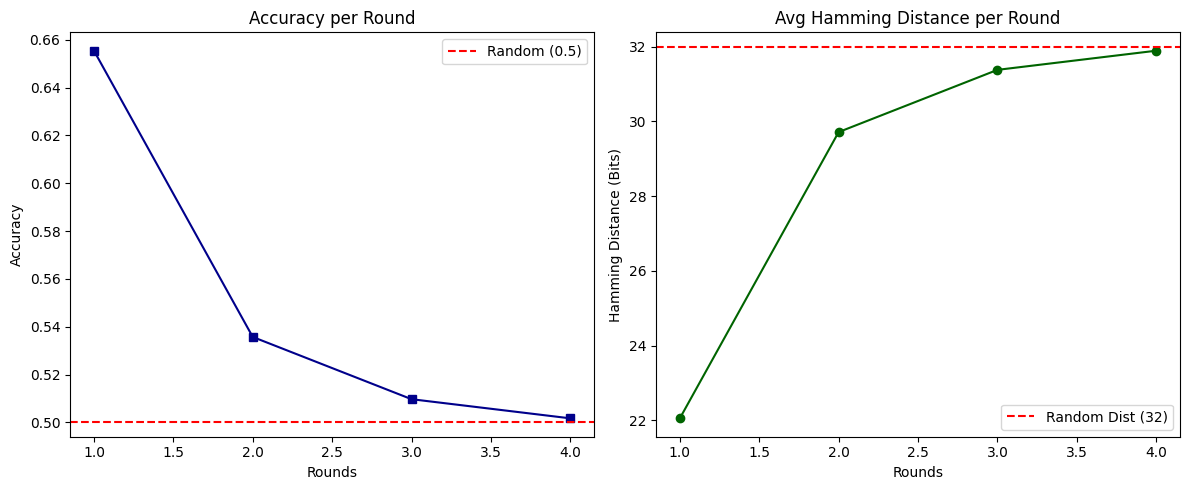

In [1]:
import numpy as np
import random
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, hamming_loss  # Added hamming_loss
import matplotlib.pyplot as plt

SBOX = [0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD, 0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2]

PBOX = [0, 16, 32, 48, 1, 17, 33, 49, 2, 18, 34, 50, 3, 19, 35, 51,
        4, 20, 36, 52, 5, 21, 37, 53, 6, 22, 38, 54, 7, 23, 39, 55,
        8, 24, 40, 56, 9, 25, 41, 57, 10, 26, 42, 58, 11, 27, 43, 59,
        12, 28, 44, 60, 13, 29, 45, 61, 14, 30, 46, 62, 15, 31, 47, 63]

def sbox_layer(state):
    output = 0
    for i in range(16):
        nibble = (state >> (4 * i)) & 0xF
        output |= SBOX[nibble] << (4 * i)
    return output

def p_layer(state):
    output = 0
    for i in range(64):
        bit = (state >> i) & 1
        output |= (bit << PBOX[i])
    return output

def present_round(state, round_key):
    state ^= round_key
    state = sbox_layer(state)
    state = p_layer(state)
    return state

def generate_present_data(samples, rounds, key_64):
    X, Y = [], []
    for _ in range(samples):
        pt = random.getrandbits(64)
        state = pt
        for _ in range(rounds):
            state = present_round(state, key_64)

        x_bits = [int(b) for b in format(pt, '064b')]
        y_bits = [int(b) for b in format(state, '064b')]
        X.append(x_bits)
        Y.append(y_bits)
    return np.array(X), np.array(Y)

test_rounds = [1, 2, 3, 4]
num_samples = 15000
master_key = 0x0123456789ABCDEF
round_accuracies = []
round_hammings = []  # List to store hamming distances

print(f"Starting Logistic Regression on PRESENT Cipher (Samples: {num_samples})")

for r in test_rounds:
    print(f"Processing Round {r}...")
    X_data, Y_data = generate_present_data(num_samples, r, master_key)

    split = int(num_samples * 0.8)
    X_train, X_test = X_data[:split], X_data[split:]
    Y_train, Y_test = Y_data[:split], Y_data[split:]

    model = MultiOutputClassifier(LogisticRegression(solver='liblinear', max_iter=100))
    model.fit(X_train, Y_train)

    predictions = model.predict(X_test)

    # 1. Calculate Bitwise Accuracy
    acc = accuracy_score(Y_test.flatten(), predictions.flatten())
    round_accuracies.append(acc)

    # 2. Calculate Hamming Loss and Average Hamming Distance
    h_loss = hamming_loss(Y_test, predictions)
    avg_hamming_dist = h_loss * 64  # Multiply by block size (64 bits)
    round_hammings.append(avg_hamming_dist)

    print(f"-> Round {r} | Accuracy: {acc:.4f} | Avg Hamming Distance: {avg_hamming_dist:.2f}")

# Plotting results
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(test_rounds, round_accuracies, marker='s', color='darkblue')
plt.axhline(y=0.5, color='r', linestyle='--', label='Random (0.5)')
plt.title("Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.legend()

# Plot Hamming Distance
plt.subplot(1, 2, 2)
plt.plot(test_rounds, round_hammings, marker='o', color='darkgreen')
plt.axhline(y=32, color='r', linestyle='--', label='Random Dist (32)')
plt.title("Avg Hamming Distance per Round")
plt.xlabel("Rounds")
plt.ylabel("Hamming Distance (Bits)")
plt.legend()

plt.tight_layout()
plt.show()

Dataset Generation for MLP

In [2]:
import random
import numpy as np

SBOX = [0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD, 0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2]

PBOX = [0, 16, 32, 48, 1, 17, 33, 49, 2, 18, 34, 50, 3, 19, 35, 51,
        4, 20, 36, 52, 5, 21, 37, 53, 6, 22, 38, 54, 7, 23, 39, 55,
        8, 24, 40, 56, 9, 25, 41, 57, 10, 26, 42, 58, 11, 27, 43, 59,
        12, 28, 44, 60, 13, 29, 45, 61, 14, 30, 46, 62, 15, 31, 47, 63]

def int_to_bits(x, bits=64):
    return [int(b) for b in format(x, f'0{bits}b')]

def bits_to_int(bits):
    return int("".join(map(str, bits)), 2)

def sbox_layer(state):
    output = 0
    for i in range(16):
        nibble = (state >> (4*i)) & 0xF
        output |= SBOX[nibble] << (4*i)
    return output

def p_layer(state):
    bits = int_to_bits(state, 64)
    permuted = [0]*64
    for i in range(64):
        permuted[PBOX[i]] = bits[i]
    return bits_to_int(permuted)

def present_round(state, key):
    state ^= key
    state = sbox_layer(state)
    state = p_layer(state)
    return state

def present_encrypt(p, key, rounds):
    state = p
    for _ in range(rounds):
        state = present_round(state, key & 0xFFFFFFFFFFFFFFFF)
    return state

def generate_dataset(samples, rounds, key):

    X = []
    Y = []

    for _ in range(samples):

        p1 = random.getrandbits(64)
        p2 = random.getrandbits(64)

        c1 = present_encrypt(p1, key, rounds)
        c2 = present_encrypt(p2, key, rounds)

        dp = p1 ^ p2
        dc = c1 ^ c2

        X.append(int_to_bits(dp))
        Y.append(int_to_bits(dc))

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

if __name__ == "__main__":

    key = random.getrandbits(80)
    samples = 40000

    print("Using key:", hex(key))

    for r in range(1, 6):

        print(f"\nGenerating dataset for round {r}")

        X, Y = generate_dataset(samples, r, key)

        np.save(f"present_r{r}_X.npy", X)
        np.save(f"present_r{r}_Y.npy", Y)

        print("Saved:", X.shape, Y.shape)

Using key: 0x5152a9a1b470ee1d9ab3

Generating dataset for round 1
Saved: (40000, 64) (40000, 64)

Generating dataset for round 2
Saved: (40000, 64) (40000, 64)

Generating dataset for round 3
Saved: (40000, 64) (40000, 64)

Generating dataset for round 4
Saved: (40000, 64) (40000, 64)

Generating dataset for round 5
Saved: (40000, 64) (40000, 64)


MLP model

Using device: cuda

Training Round 1 on GPU...
Accuracy: 0.6000 | Hamming Distance: 25.5971

Training Round 2 on GPU...
Accuracy: 0.5006 | Hamming Distance: 31.9626

Training Round 3 on GPU...
Accuracy: 0.5003 | Hamming Distance: 31.9788

Training Round 4 on GPU...
Accuracy: 0.5001 | Hamming Distance: 31.9960

Training Round 5 on GPU...
Accuracy: 0.5003 | Hamming Distance: 31.9833


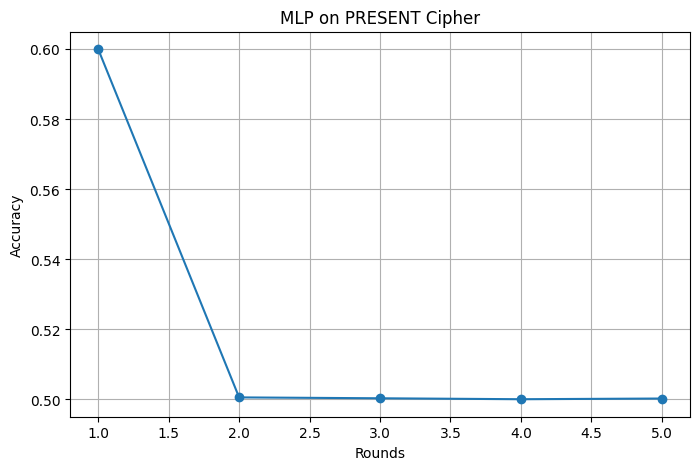

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class PresentMLP(nn.Module):
    def __init__(self):
        super(PresentMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(64, 256), # Input size matches 64-bit block
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

def evaluate_gpu(X, Y):
    # Split data
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    X_train_t = torch.FloatTensor(X_train)
    Y_train_t = torch.FloatTensor(Y_train)
    X_test_t = torch.FloatTensor(X_test).to(device)
    Y_test_t = torch.FloatTensor(Y_test).to(device)

    train_dataset = TensorDataset(X_train_t, Y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

    model = PresentMLP().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 50
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t)
        preds = (preds > 0.5).float()

        accuracy = (preds == Y_test_t).float().mean().item()

        hamming = torch.mean(torch.sum(preds != Y_test_t, dim=1).float()).item()

    return accuracy, hamming

rounds, acc_list, ham_list = [], [], []

for r in range(1, 6):
    print(f"\nTraining Round {r} on GPU...")
    try:
        X = np.load(f"present_r{r}_X.npy")
        Y = np.load(f"present_r{r}_Y.npy")

        acc, ham = evaluate_gpu(X, Y)

        print(f"Accuracy: {acc:.4f} | Hamming Distance: {ham:.4f}")
        rounds.append(r)
        acc_list.append(acc)
        ham_list.append(ham)
    except FileNotFoundError:
        print(f"Files for round {r} not found.")

plt.figure(figsize=(8,5))
plt.plot(rounds, acc_list, marker='o')
plt.xlabel("Rounds"); plt.ylabel("Accuracy")
plt.title("MLP on PRESENT Cipher")
plt.grid(); plt.show()

Dataset Generation for CNN

In [4]:
import random
import numpy as np

SBOX = [
    0xC, 0x5, 0x6, 0xB,
    0x9, 0x0, 0xA, 0xD,
    0x3, 0xE, 0xF, 0x8,
    0x4, 0x7, 0x1, 0x2
]

PBOX = [
    0,16,32,48,1,17,33,49,
    2,18,34,50,3,19,35,51,
    4,20,36,52,5,21,37,53,
    6,22,38,54,7,23,39,55,
    8,24,40,56,9,25,41,57,
    10,26,42,58,11,27,43,59,
    12,28,44,60,13,29,45,61,
    14,30,46,62,15,31,47,63
]

def int_to_bits(x, bits=64):
    return [int(b) for b in format(x, f'0{bits}b')]

def bits_to_int(bits):
    return int("".join(map(str, bits)), 2)

def sbox_layer(state):
    output = 0
    for i in range(16):
        nibble = (state >> (4*i)) & 0xF
        output |= SBOX[nibble] << (4*i)
    return output

def p_layer(state):
    bits = int_to_bits(state, 64)
    permuted = [0]*64
    for i in range(64):
        permuted[PBOX[i]] = bits[i]
    return bits_to_int(permuted)

def present_round(state, key):
    state ^= key
    state = sbox_layer(state)
    state = p_layer(state)
    return state

def present_encrypt(p, key, rounds):
    state = p
    for _ in range(rounds):
        state = present_round(state, key & 0xFFFFFFFFFFFFFFFF)
    return state

def generate_dataset(samples, rounds, key):

    X = []
    Y = []

    delta = 0x00000000000000FF   # 🔥 fixed difference

    for _ in range(samples):

        p1 = random.getrandbits(64)
        p2 = p1 ^ delta

        c1 = present_encrypt(p1, key, rounds)
        c2 = present_encrypt(p2, key, rounds)

        dp = p1 ^ p2
        dc = c1 ^ c2

        X.append(int_to_bits(dp))
        Y.append(int_to_bits(dc))

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

if __name__ == "__main__":

    key = random.getrandbits(80)
    samples = 60000
    print("Using key:", hex(key))
    for r in range(1, 6):
        print(f"\nGenerating dataset for round {r}")
        X, Y = generate_dataset(samples, r, key)
        np.save(f"presen_r{r}_X.npy", X)
        np.save(f"presen_r{r}_Y.npy", Y)
        print("Saved:", X.shape, Y.shape)

Using key: 0xae04ee0b36f07c44dee0

Generating dataset for round 1
Saved: (60000, 64) (60000, 64)

Generating dataset for round 2
Saved: (60000, 64) (60000, 64)

Generating dataset for round 3
Saved: (60000, 64) (60000, 64)

Generating dataset for round 4
Saved: (60000, 64) (60000, 64)

Generating dataset for round 5
Saved: (60000, 64) (60000, 64)


CNN model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class PresentCNN(nn.Module):
    def __init__(self):
        super(PresentCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 64, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# 3. TRAIN FUNCTION (GPU ENABLED)
def train_model(X, Y, round_num):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    X_train = torch.tensor(X_train).float().unsqueeze(1)
    Y_train = torch.tensor(Y_train).float()
    X_test = torch.tensor(X_test).float().unsqueeze(1).to(device)
    Y_test = torch.tensor(Y_test).float().to(device)

    train_dataset = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

    model = PresentCNN().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    for epoch in range(25):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

    # SAVE MODEL
    torch.save(model.state_dict(), f"present_cnn_r{round_num}.pth")

    # EVALUATE
    model.eval()
    with torch.no_grad():
        preds = (model(X_test) > 0.5).float()
        # .float() fix included to avoid the mean() error
        accuracy = (preds == Y_test).float().mean().item()
        hamming = torch.mean(torch.sum(preds != Y_test, dim=1).float()).item()

    return accuracy, hamming

# 4. MAIN EXECUTION
for r in range(1, 6):
    print(f"\n--- Training Round {r} ---")
    X = np.load(f"presen_r{r}_X.npy")
    Y = np.load(f"presen_r{r}_Y.npy")
    acc, ham = train_model(X, Y, r)
    print(f"Accuracy: {acc:.4f} | Hamming: {ham:.4f}")

Using device: cuda

--- Training Round 1 ---
Accuracy: 0.9453 | Hamming: 3.5035

--- Training Round 2 ---


Generalization

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
class PresentCNN(torch.nn.Module):
    def __init__(self):
        super(PresentCNN, self).__init__()
        self.conv1 = torch.nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.bn1 = torch.nn.BatchNorm1d(64)
        self.conv2 = torch.nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = torch.nn.BatchNorm1d(128)
        self.conv3 = torch.nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.BatchNorm1d(128)
        self.dropout = torch.nn.Dropout(0.3)
        self.fc1 = torch.nn.Linear(128 * 64, 256)
        self.fc2 = torch.nn.Linear(256, 128)
        self.fc3 = torch.nn.Linear(128, 64)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

def run_generalization_test():
    rounds = range(1, 6)
    gen_accs = []

    print(f"{'Round':<10} | {'Unseen Data Accuracy':<20}")
    print("-" * 35)

    for r in rounds:
        try:
            X_gen = np.load(f"presen_r{r}_X.npy")
            Y_gen = np.load(f"presen_r{r}_Y.npy")

            X_gen_t = torch.tensor(X_gen).float().unsqueeze(1)
            Y_gen_t = torch.tensor(Y_gen).float()

            # 2. Load the Weights
            model = PresentCNN()
            model.load_state_dict(torch.load(f"present_cnn_r{r}.pth"))
            model.eval()

            # 3. Test
            with torch.no_grad():
                preds = (model(X_gen_t) > 0.5).float()
                acc = (preds == Y_gen_t).float().mean().item()
                gen_accs.append(acc)
                print(f"Round {r:<5} | {acc:.4f}")
        except FileNotFoundError:
            print(f"Round {r:<5} | Missing .pth or .npy files")

    # Plotting
    plt.plot(list(rounds), gen_accs, marker='s', color='purple', label='Generalization')
    plt.axhline(0.5, color='red', linestyle='--')
    plt.title("PRESENT CNN: Generalization to Unseen Plaintexts")
    plt.xlabel("Rounds"); plt.ylabel("Accuracy")
    plt.show()

if __name__ == "__main__":
    run_generalization_test()